In [2]:
# Some used imports
%matplotlib inline
import pandas as pd
import numpy as np
import os
import glob
import matplotlib as mpl
# import datetime as dt

# Just making the plots look better
mpl.style.use('ggplot')
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['font.size'] = 12

#Read in IMDB dataframe
df = pd.read_csv('../../Downloads/The-office-imdb.csv')
df.columns=['season', 'title', 'airdate', 'rating', 'votes', 'description', 'directors', 'writers']
df['writers'] = df['writers'].apply(lambda x : x.replace(' | ', ',').replace(' |', ',').replace(' and ', ',').split(','))
df['directors'] = df['directors'].apply(lambda x : x.replace(' | ', ',').replace(' |', ',').replace(' and ', ',').split(','))
df.head(10)

,season,title,airdate,rating,votes,description,directors,writers
0,1,Pilot,2005-03-24,7.5,4349,The premiere episode introduces the boss and s...,[Ken Kwapis],"[Ricky Gervais, Stephen Merchant, Greg Daniels]"
1,1,Diversity Day,2005-03-29,8.3,4213,Michael's off color remark puts a sensitivity ...,[Ken Kwapis],[B. J. Novak]
2,1,Health Care,2005-04-05,7.8,3536,Michael leaves Dwight in charge of picking the...,[Ken Whittingham],[Paul Lieberstein]
3,1,The Alliance,2005-04-12,8.1,3428,"Just for a laugh, Jim agrees to an alliance wi...",[Bryan Gordon],[Michael Schur]
4,1,Basketball,2005-04-19,8.4,3745,Michael and his staff challenge the warehouse ...,[Greg Daniels],[Greg Daniels]
5,1,Hot Girl,2005-04-26,7.8,3372,Michael is just one of the many male staff who...,[Amy Heckerling],[Mindy Kaling]
6,2,The Dundies,2005-09-20,8.7,3780,"Very much unlike his staff, an overeager Micha...",[Greg Daniels],[Mindy Kaling]
7,2,Sexual Harassment,2005-09-27,8.2,3218,The office reviews its sexual harassment polic...,[Ken Kwapis],[B. J. Novak]
8,2,Office Olympics,2005-10-04,8.4,3218,"Ready to finalize his deal for a new condo, Mi...",[Paul Feig],[Michael Schur]
9,2,The Fire,2005-10-11,8.4,3183,A fire in the kitchen relegates the staff to t...,[Ken Kwapis],[B. J. Novak]


In [3]:
# Read in both lines dataframes
df3 = pd.read_csv('../../Downloads/The-Office-Lines.csv')
df1 = pd.read_csv('../../Downloads/The-Office-Lines-V2.csv')

# outer join to get all missing scenes in dataset v2
df2 = pd.merge(df3, df1, how='outer')
# df2.to_csv("hi")

In [4]:
# Clean strings by removing whitespace and lowercasing when necessary
df2['scene'] = df2['scene'].fillna(0)
df2['speaker'] = df2['speaker'].apply(lambda x : x.strip().lower())
df2['line'] = df2['line'].apply(lambda x : x.lower())
df2['scene'] = df2['scene'].astype(np.int64)
df2['title'] = df2['title'].apply(lambda x : x.lower())
df2.replace(to_replace={"speaker": {"michel": "michael", 
                                    "micheal": "michael",
                                    "michal": "michael",
                                    "miichael": "michael",
                                    "michael:": "michael",
                                    "m ichael": "michael",
                                    "micael": "michael",
                                    "michae": "michael",
                                    "micahel": "michael",
                                    "mihael": "michael",
                                    "phylis": "phyllis",
                                    "phyliss": "phyllis",
                                    "phyllis:": "phyllis",
                                    "\"phyllis\"": "phyllis",
                                    "anglea": "angela",
                                    "\"angela\"": "angela",
                                    "jim:": "jim",
                                    "meredith:": "meredith",
                                    "angela:": "angela",
                                    "creed:": "creed",
                                    "oscar:": "oscar",
                                    "stanley:": "stanley",
                                    "darryl:": "darryl",
                                    "andy:": "andy",
                                    "pam:": "pam",
                                    "erin:": "erin",
                                    "kevin:": "kevin",
                                    "ryan:": "ryan",
                                    "dwight.": "dwight",
                                    "darrly": "darryl",
                                    "meridith": "meredith",
                                    "dight": "dwight",
                                    "holy": "holly",
                                    "\"jim\"": "jim",
                                    "kelly:": "kelly",
                                    "daryl": "darryl",
                                    "stanely": "stanley",
                                    "": "david wallace",
                                    "dacvid wallace": "david wallace",
                                    "david wallcve": "david wallace",
                                    "dacvid walalce": "david wallace",
                                    "dwight [on phone]": "dwight",
                                    "dwight:":"dwight"}},inplace=True)
df2.head()

,season,episode,title,speaker,line,scene
0,1,1,pilot,michael,all right jim. your quarterlies look very good...,1
1,1,1,pilot,jim,"oh, i told you. i couldn't close it. so...",1
2,1,1,pilot,michael,so you've come to the master for guidance? is ...,1
3,1,1,pilot,jim,"actually, you called me in here, but yeah.",1
4,1,1,pilot,michael,"all right. well, let me show you how it's done.",1


In [5]:
# RANDOM FUNCTIONS

# Get max IMDB rating for an episode
# df["rating"].max()

# List all unique speakers in The Office
# df2['speaker'].unique().tolist()

# To get number of unique speakers in The Office: len(df2['speaker'].unique().tolist())

# # df.select(speaker phyllis   
# #          season 2
# #          episode 8)

# def gfilter(s, e, c, df):
#     dfnew = df[(df['speaker'] == c) & (df['season'] == s) & (df['episode'] == e)]
#     return(dfnew)

# gfilter(2, 8, "phyllis", df2)

# def gfilter(s, c, df):
#     dfnew = df[(df['speaker'] == c) & (df['scene'] == s)]
#     return(dfnew)

# gfilter(7860, "jim", df2)

# calc # of unique episodes in each season
df4 = df2.groupby(['season'])['episode'].nunique().reset_index(name = "eps")
df4
# df4['eps'].sum()
# # df2.groupby(['season', 'episode'])['speaker'].nunique().reset_index(name = "# of spkrs in episode")

# df2.groupby(['speaker'])['line'].nunique().reset_index(name = "# of lines").sort_values(by="# of lines", ascending=False)

,season,eps
0,1,6
1,2,22
2,3,23
3,4,14
4,5,27
5,6,24
6,7,24
7,8,24
8,9,23


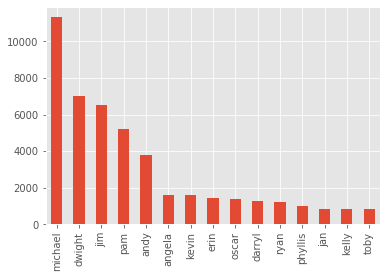

In [6]:
# Number of each character's total lines in the entire show
df2['speaker'].value_counts().head(15)
df2['speaker'].value_counts().head(15).plot.bar();

In [7]:
# Number of scenes that a character spoke in 
g = df2.groupby(['speaker', 'scene']).size().reset_index(name = "# of lines in scene")
g.groupby(['speaker']).size().to_frame(name = 'no scenes').reset_index().sort_values(by='no scenes', ascending=False).head(5)

,speaker,no scenes
422,michael,2743
200,dwight,2168
328,jim,1984
493,pam,1805
24,andy,1225


In [8]:
# Number of episodes that each character spoke in
g2 = df2.groupby(['speaker', 'season', 'episode']).size().reset_index(name = "no lines in episode")

# g3 = g2.groupby(['speaker', 'season', 'episode']).size().to_frame(name = 'speaks in ep').reset_index()
# g3.groupby(['speaker']).size().to_frame(name = 'size').reset_index().sort_values(by='size', ascending=False).head(5)

g2.sort_values(by='no lines in episode', ascending=False)

,speaker,season,episode,no lines in episode
2889,pam,6,17,188
2407,michael,4,18,167
2438,michael,6,6,155
2396,michael,4,5,150
1630,jim,6,17,146
...,...,...,...,...
1264,everyone,8,17,1
3235,receptionitis15 [screen name],5,1,1
3236,redheaded actress,2,2,1
3237,registrar,6,11,1


In [9]:
# Create DataFrame of # of lines per speaker per season
num_spkr_lines = df2.groupby(['season', 'speaker']).size().reset_index(name="lines")
# Sort number of lines per speaker per season, from most to least
num_spkr_lines.sort_values(by='lines', ascending=False)

# Number of lines per speaker per episode
num_spkr_lines2 = df2.groupby(['season', 'speaker', 'episode']).size().reset_index(name="lines")
num_spkr_lines2

# SPEAKER LINES PER EP = num_spkr_lines2

# num_spkr_lines3 = df2.groupby(['speaker']).size().reset_index(name="lines")
# num_spkr_lines3.sort_values(by='lines', ascending=False)

,season,speaker,episode,lines
0,1,angela,1,1
1,1,angela,2,4
2,1,angela,3,5
3,1,angela,4,7
4,1,angela,5,3
...,...,...,...,...
3918,9,woman 4,24,2
3919,9,worker,10,1
3920,9,zeke,13,4
3921,9,zeke,17,9


In [10]:
# TOTAL lines per season
lines_per_szn = df2.groupby(['season']).size().reset_index(name="lines")
lines_per_szn = lines_per_szn.set_index(['season'])
# print(lines_per_szn.lines)

# TOTAL lines per episode = lines_per_ep
lines_per_ep = df2.groupby(['season', 'episode']).size().reset_index(name="lines")
lines_per_ep.head(1000).tail(100)

,season,episode,lines
87,5,25,290
88,5,26,329
89,5,27,279
90,5,28,274
91,5,30,1
...,...,...,...
182,9,19,262
183,9,20,233
184,9,21,392
185,9,22,517


In [11]:
# join lines per ep and & num_spkr_lines2 on season & episode
# rename lines_per_ep 's lines column to total_lines
lines_master = pd.merge(num_spkr_lines2, lines_per_ep, how='outer', on=['season', 'episode'])
lines_master.columns = ['season', 'speaker', 'episode',  'speaker_lines', 'total_lines']
lines_master.sort_values(by='episode',ascending=False).head(190).tail(30)

,season,speaker,episode,speaker_lines,total_lines
2217,6,shane,25,11,332
2218,6,stanley,25,2,332
3340,8,pam,24,24,305
3341,8,photographer,24,2,305
3324,8,creed,24,1,305
3339,8,others,24,1,305
3343,8,ravi,24,1,305
3320,8,andy,24,51,305
838,3,andy,24,22,507
839,3,angela,24,6,507


In [12]:
lines_master['percent'] = (lines_master['speaker_lines']/lines_master['total_lines']).round(decimals=5)*100

# create ideal percents table
line_percents = lines_master[['season', 'episode', 'speaker', 'percent']]

# test line percents df for summing to 100
line_percents.query("episode == 3 & season == 9")['percent'].sum()

99.999

In [13]:
line_percents.tail(70)

,season,episode,speaker,percent
3853,9,10,both,0.389
3854,9,10,creed,1.556
3855,9,10,darryl,5.837
3856,9,10,dwight,7.004
3857,9,10,erin,10.117
...,...,...,...,...
3918,9,14,party waiter,0.382
3919,9,14,phyllis,0.382
3920,9,14,senator,3.053
3921,9,14,toby,1.145


In [14]:
# Add episode to IMDB list

s_counter = 1
e_counter = 1
eps = []
for row in df.itertuples():
    if row.season == s_counter:
        eps.append(e_counter)
        e_counter += 1
    else:
        eps.append(1)
        s_counter += 1
        e_counter = 2
len(eps)

df['episode'] = eps
df

#SZN 3 should go from ep 10-> 12 ( a benihana xmas)
#SZN 4 should go from ep 1-> 3 (fun run) 3->5 (dund mifflin inf) 5->7 (launch party) 7->9 (money)
#SZN 5 1->3 (weight loss) 14->16 (stress relief)
# SZN 7 11->13
# SZN 9 22 -> 24


,season,title,airdate,rating,votes,description,directors,writers,episode
0,1,Pilot,2005-03-24,7.5,4349,The premiere episode introduces the boss and s...,[Ken Kwapis],"[Ricky Gervais, Stephen Merchant, Greg Daniels]",1
1,1,Diversity Day,2005-03-29,8.3,4213,Michael's off color remark puts a sensitivity ...,[Ken Kwapis],[B. J. Novak],2
2,1,Health Care,2005-04-05,7.8,3536,Michael leaves Dwight in charge of picking the...,[Ken Whittingham],[Paul Lieberstein],3
3,1,The Alliance,2005-04-12,8.1,3428,"Just for a laugh, Jim agrees to an alliance wi...",[Bryan Gordon],[Michael Schur],4
4,1,Basketball,2005-04-19,8.4,3745,Michael and his staff challenge the warehouse ...,[Greg Daniels],[Greg Daniels],5
...,...,...,...,...,...,...,...,...,...
192,9,Paper Airplane,2013-04-25,8.0,1748,The employees hold a paper airplane competitio...,[Jesse Peretz],"[Halsted Sullivan, Warren Lieberstein]",20
193,9,Livin' the Dream,2013-05-02,9.0,2439,Dwight becomes regional manager after Andy qui...,[Jeffrey Blitz],[Niki Schwartz-Wright],21
194,9,A.A.R.M.,2013-05-09,9.5,3401,Dwight prepares for a marriage proposal and hi...,[David Rogers],[Brent Forrester],22
195,9,A.A.R.M.,2013-05-09,9.5,3401,Dwight prepares for a marriage proposal and hi...,[David Rogers],[Brent Forrester],23


In [79]:
rating_df = df[['season', 'episode', 'rating', 'title', 'airdate']]
# rating_df.head(100).tail(30)
ratin_master = pd.merge(line_percents, rating_df, how='inner', on=['season', 'episode'])
ratin_master
# line_percents.to_csv("spkr-percents-by-ep.csv")


# rating_df.head(140).tail(10)
rating_df = rating_df.drop(index=38)
rating_df = rating_df.drop(index=195)
rating_df = rating_df.drop(index=53)
rating_df = rating_df.drop(index=55)
rating_df = rating_df.drop(index=57)
rating_df = rating_df.drop(index=59)
rating_df = rating_df.drop(index=71)
rating_df = rating_df.drop(index=84)
rating_df = rating_df.drop(index=135)
rating_df.to_csv("ratings-per-ep.csv")

In [75]:
# Let us check whether there are any missing values in the data set
ratin_master.isnull().sum()

season     0
episode    0
speaker    0
percent    0
rating     0
title      0
airdate    0
dtype: int64

In [17]:
# Custom functions to filter dataframe by character, season, and both.
# c = character name (str), s = season number (int), df = dataframe (with a season/speaker column)
def filter_by_spkr_and_szn(c, s, df):
    dfnew = df[(df['speaker']==c) & (df['season']==s)]
    return(dfnew)

def c_filter(s, df):
    dfnew = df[(df['speaker'] == s)]
    return(dfnew)

def s_filter(s, df):
    dfnew = df[(df['season'] == s)]
    return(dfnew)

In [18]:
# Test out lines per speaker for season (top 5 speakers)
for i in range(1,10):
    print(s_filter(i, num_spkr_lines).sort_values(by='lines', ascending=False).head(5))

    season  speaker  lines
14       1  michael    500
5        1      jim    230
2        1   dwight    220
18       1      pam    172
6        1     katy     60
     season  speaker  lines
105       2  michael   1897
63        2   dwight    829
84        2      jim    765
116       2      pam    621
83        2      jan    254
     season  speaker  lines
207       3  michael   1758
173       3   dwight    824
189       3      jim    722
214       3      pam    615
143       3     andy    302
     season  speaker  lines
306       4  michael   1428
293       4      jim    596
275       4   dwight    485
320       4      pam    469
331       4     ryan    203
     season  speaker  lines
424       5  michael   2165
376       5   dwight   1065
402       5      jim    866
436       5      pam    709
354       5     andy    481
     season  speaker  lines
567       6  michael   2106
543       6      jim    980
509       6   dwight    859
583       6      pam    777
483       6     andy    53

In [19]:
print ("Average Rating by Season:")
# Go through all 9 seasons
for i in range(1,10):
    # Get a table of top speakers from that season
    filtered = s_filter(i, num_spkr_lines)
    # Get ID of row with max # of lines
    maxes = map(str.capitalize, filtered.nlargest(5, 'lines').speaker.to_list())
    # Print out speaker with that ID
    print("Season " + str(i) + ":\n Top Speakers: " + ', '.join(maxes) + "\n Rating: " + str(s_filter(i, df).rating.mean().round(decimals=2)) + "\n" +"-"*50)

Average Rating by Season:
Season 1:
 Top Speakers: Michael, Jim, Dwight, Pam, Katy
 Rating: 7.98
--------------------------------------------------
Season 2:
 Top Speakers: Michael, Dwight, Jim, Pam, Jan
 Rating: 8.45
--------------------------------------------------
Season 3:
 Top Speakers: Michael, Dwight, Jim, Pam, Andy
 Rating: 8.61
--------------------------------------------------
Season 4:
 Top Speakers: Michael, Jim, Dwight, Pam, Ryan
 Rating: 8.56
--------------------------------------------------
Season 5:
 Top Speakers: Michael, Dwight, Jim, Pam, Andy
 Rating: 8.55
--------------------------------------------------
Season 6:
 Top Speakers: Michael, Jim, Dwight, Pam, Andy
 Rating: 8.2
--------------------------------------------------
Season 7:
 Top Speakers: Michael, Dwight, Jim, Pam, Andy
 Rating: 8.35
--------------------------------------------------
Season 8:
 Top Speakers: Andy, Dwight, Jim, Pam, Erin
 Rating: 7.63
--------------------------------------------------
Sea

In [20]:
toby = c_filter("toby", num_spkr_lines)
for i in range(1,10):
    toby_by_szn = s_filter(i, toby)
    tobys_lines = toby_by_szn.lines.values[0]
    # print(tobys_lines)
    # print(lines_per_szn.lines[i])
    # print(str((tobys_lines/lines_per_szn.lines[i]*100).round(decimals=4)) + "%")
    print("Rating of Season " + str(i) + " (Toby has " + str((tobys_lines/lines_per_szn.lines[i]*100).round(decimals=4)) + "%" + " of lines): " + str(s_filter(i, df).rating.mean().round(decimals=2)))


Rating of Season 1 (Toby has 0.7869% of lines): 7.98
Rating of Season 2 (Toby has 1.7175% of lines): 8.45
Rating of Season 3 (Toby has 1.5917% of lines): 8.61
Rating of Season 4 (Toby has 2.2598% of lines): 8.56
Rating of Season 5 (Toby has 0.8292% of lines): 8.55
Rating of Season 6 (Toby has 1.2644% of lines): 8.2
Rating of Season 7 (Toby has 1.2817% of lines): 8.35
Rating of Season 8 (Toby has 1.4661% of lines): 7.63
Rating of Season 9 (Toby has 1.7155% of lines): 7.99


In [21]:
print(filter_by_spkr_and_szn("michael", 6, num_spkr_lines))

     season  speaker  lines
567       6  michael   2106


In [22]:
# Write a function to tell what percent of lines a character has in a season. RETURNS A FLOAT
# def percent_lines_in_szn(c, s):
#     c_lines = filter_by_spkr_and_szn(c, s, num_spkr_lines).lines.values[0]
#     total_lines = lines_per_szn.lines[s]
#     return (c_lines/total_lines*100).round(decimals=2)
#########
# test function: percent lines michael has in season 1
# percent_lines_in_szn("michael", 1)
#########
# for i in range(1,10):
#     print("season " + str(i) + ": " + str(percent_lines_in_szn("dwight", i)) + "%")

In [23]:
df6 = df2.groupby(['season', 'episode'])['speaker'].unique().reset_index()
for i in range(0, 186):
    if "dwight" not in df6['speaker'][i]:
        print(str(df6['season'][i]) + str(df6['episode'][i]) + "no")            

530no


In [24]:
df6.head()

,season,episode,speaker
0,1,1,"[michael, jim, pam, dwight, jan, todd packer, ..."
1,1,2,"[michael, mr. brown, jim, dwight, pam, oscar, ..."
2,1,3,"[michael, pam, jan, jim, dwight, stanley, osca..."
3,1,4,"[dwight, michael, stanley, pam, phyllis, angel..."
4,1,5,"[michael, dwight, jim, phyllis, pam, ryan, lon..."
